In [1]:
import locale


def getpreferredencoding(do_setlocale=True):
    return "UTF-8"


locale.getpreferredencoding = (
    getpreferredencoding  # ensure that Google Colab works with shell commands
)

!pip install reflectorch
#!pip install git+https://github.com/schreiber-lab/reflectorch.git


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch

from ipywidgets import widgets, interact
from pathlib import Path
from reflectorch import *
from reflectorch.extensions.jupyter import JPlotLoss

torch.manual_seed(0)  # set seed for reproducibility

# 4. How to train a model

The default paths for storing the configuration files and the model weights are relative to the package installation directory.

In [3]:
print(CONFIG_DIR, "\n", SAVED_MODELS_DIR)

/home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/configs 
 /home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/saved_models


In the following we will create new locations for storing the configuration files and model weights, relative to our current working directory.

In [4]:
!mkdir configs
!mkdir saved_models
!ls

mkdir: cannot create directory ‘configs’: File exists
mkdir: cannot create directory ‘saved_models’: File exists
configs   explore_reflectorch.ipynb  Pipfile.lock
data	  maria.ipynb		     saved_models
exp_data  Pipfile		     training_reflectorch.ipynb


For training a model we use the `Trainer` class, which contains all the components necessary for the training process such as the data generator, the neural network and the optimizer.

 We can initialize the trainer according to the specifications defined in a YAML configuration file using the `get_trainer_by_name` method which takes as input the name of the configuration file. If the package was installed in editable model, the configuration files are read from the `configs` directory located inside the repository, otherwise the path to the directory containing the configuration file should also be specified using the `config_dir`
 argument. The `load_weights` argument should be set to `False` since we want the neural network weights to be randomly initialized for a fresh training.


In [5]:
config_name = "c1"

**Note**: for training on the CPU, all the `device` arguments in the configuration file would have to be changed to `cpu` instead of `cuda`.

In [6]:
trainer = get_trainer_by_name(
    config_name=config_name, config_dir="configs/", load_weights=False
)

Model c1 loaded. Number of parameters: 3.83 M


The trainer contains several important attributes we can inspect:

  1. The Pytorch optimizer:

In [7]:
trainer.optim

AdamW (
Parameter Group 0
    amsgrad: False
    betas: [0.9, 0.999]
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)

  2. The batch size:

In [8]:
trainer.batch_size

4096

  3. The Pytorch neural network module. We can see that the network is an instance of the class `PriorInformedNetworkConvEmb`. This architecture consists of a multilayer perceptron (MLP) with residual connections, batch normalization layers and GELU activations (`trainer.model.mlp`). A 1D CNN embedding network (`trainer.model.embedding_net`) produces a latent embedding of the input batch of reflectivity curves which is concatenated with the prior bounds for the thin film parameters.

In [9]:
trainer.model

NetworkWithPriorsConvEmb(
  (embedding_net): ConvEncoder(
    (core): Sequential(
      (0): Sequential(
        (0): Conv1d(1, 32, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
      (1): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
      (2): Sequential(
        (0): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
      (3): Sequential(
        (0): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(ap

We can control the training process using callback objects, such as:

  1. `JPlotLoss` - allows the interactive visualization of the loss curve when training inside a Jupyter Notebook, the `frequency` argument setting the refresh rate of the interactive widget

  2. `StepLR` - implements a learning rate scheduler which decreases the learning rate in steps (after a number of iterations defined by `step_size` the learning rate is multiplied by the factor `gamma`). Other types of learning rate schedulers can alternatively be used, such as `CyclicLR`, `LogCyclicLR`, `OneCycleLR` or `ReduceLROnPlateau`.

  3. `SaveBestModel` - it enables the periodic saving of the weights of the neural network during training. After a number of iterations defined by the `freq` argument, the weights of the neural network are saved at the specified `path` if the current average loss (computed over the last `average` iterations) is lower than the loss for the previous save. The history of the losses and learning rate values is also saved.

We defined a callback for saving model weights in the previously created `saved_models` directory and we group the callback objects together in a tuple:

In [10]:
print(Path("saved_models").absolute())

save_model_name = "model_" + config_name + ".pt"
save_path = str(Path("saved_models") / save_model_name)  #

callbacks = (
    JPlotLoss(frequency=10),
    StepLR(step_size=5000, gamma=0.1, last_epoch=-1),
    SaveBestModel(path=save_path, freq=100, average=10),
)

/home/levytskyi/Documents/reflectorch api playground/saved_models


The training process is initiated by calling the `train` method of the trainer. This method accepts as arguments the previously defined tuple of callbacks, as well as the number of iterations (batches). Notably, a new batch of data is generated at each iteration, the training taking place in a "one-epoch regime".

In [11]:
!CUDA_LAUNCH_BLOCKING=1

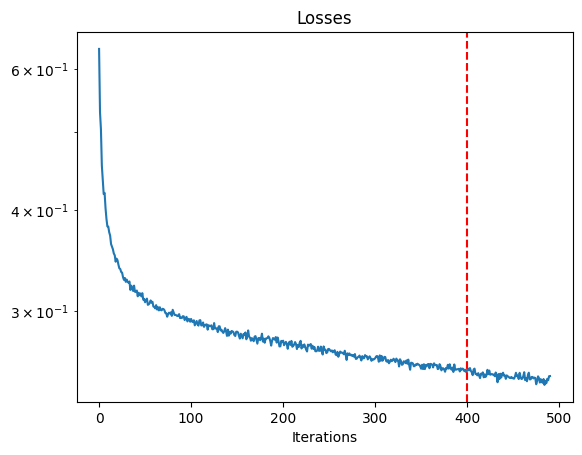

Loss = 2.45e-01: 100%|██████████| 500/500 [01:46<00:00,  4.68it/s, loss=0.2435, lr=1.00e-04]


In [12]:
# We train for a small number of iterations just for testing the functionality. Training for extended amount in Google Colab will exhaust you limited allocated resources.

trainer.train(num_batches=500, callbacks=callbacks)

We can check that the model weights have been saved in the directory:

In [13]:
torch.load(save_path, weights_only=False).keys()

dict_keys(['model', 'lrs', 'losses', 'prev_save', 'batch_num', 'best_loss'])

# 5. How to use a trained model for inference

The `EasyInferenceModel` class simplifies the inference step for single reflectivity curves. We initialize the inference model by providing the name of the configuration file of a pretrained model (`config_name`), either with or without the '.yaml' extension. By default, the file name of the saved model weights for a specific configuration has the format 'model_' + config_name + '.safetensors', but a different file name can be specified via the `model_name` argument. The `root_dir` argument can be used to specify a project directory containing the `configs` and `saved_models` subdirectories (containing the configurations and model weights, respectively), if different from the default package directory. If the configuration or weights files are not found locally, they can be downloaded automatically from the Huggingface repository specified with the `repo_id` argument. Additionally, the `device` argument can be set to either `cuda` (for inference on the GPU) or `cpu` (for computers without a GPU with CUDA support).

We create and instance of the inference class, which also prints some details about the model such as the parameter ranges.

The configuration and weight files are not found locally so they are automatically downloaded from Huggingface.

Notably, here we specify a new root directory (which should contain the `configs` and `saved_models` directories), which is specific to the Google Colab filesystem.

In [17]:
inference_model = EasyInferenceModel(
    config_name="mc25",
    model_name=None,  # since the model weight file satisfies the naming format 'model_' + config_name + '.safetensors'
    # root_dir='/', #specific to Google Colab
    repo_id="valentinsingularity/reflectivity",
    device="cuda",
)

Configuration file `/home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/configs/mc25.yaml` found locally.
Weights file `/home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/saved_models/model_mc25.safetensors` found locally.
Model mc25 loaded. Number of parameters: 13.37 M
The model corresponds to a `standard_model` parameterization with 2 layers (8 predicted parameters)
Parameter types and total ranges:
- thicknesses: [0.0, 500.0]
- roughnesses: [0.0, 20.0]
- slds: [0.0, 50.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 500.0]
- roughnesses: [0.01, 20.0]
- slds: [0.01, 5.0]
The model was trained on curves discretized at 128 uniform points between q_min=0.02 and q_max=0.15
The following quantities are additional inputs to the network: prior bounds.


We download some sample reflectity data inside our local `exp_data` directory.

In [15]:
# Create the data directory if it does not exist
!mkdir -p exp_data

# Download the file
download_link = "https://raw.githubusercontent.com/schreiber-lab/reflectorch/master/exp_data/data_PTCDI-C3.txt"
print(download_link)
!wget -N -P ./exp_data/ $download_link

# List the contents of the exp_data directory
!ls ./exp_data/

https://raw.githubusercontent.com/schreiber-lab/reflectorch/master/exp_data/data_PTCDI-C3.txt
--2025-05-14 14:40:34--  https://raw.githubusercontent.com/schreiber-lab/reflectorch/master/exp_data/data_PTCDI-C3.txt
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4239 (4,1K) [text/plain]
Saving to: ‘./exp_data/data_PTCDI-C3.txt’

data_PTCDI-C3.txt   100%[===================>]   4,14K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2025-05-14 14:40:34 (27,0 MB/s) - ‘./exp_data/data_PTCDI-C3.txt’ saved [4239/4239]

data_PTCDI-C3.txt


# USING CUSTOM DATA

In [4]:
# data = np.loadtxt('exp_data/data_PTCDI-C3.txt', delimiter='\t', skiprows=1)
data = np.loadtxt("data/s000000_experimental_curve.dat", skiprows=1)
q_exp = data[..., 0]
curve_exp = data[..., 1]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())

(125,) (125,) 0.0070006 0.299986


We interpolate the reflectivity curve to the q points the model was trained on:

In [7]:
q_model = inference_model.trainer.loader.q_generator.q.cpu().numpy()
exp_curve_interp = interp_reflectivity(q_model, q_exp, curve_exp)

print(exp_curve_interp.shape)

(128,)


This is a measurement for a two-layer film in which we have some prior knowlede about the investigated system. We know the substrate is silicon on top of which sits a thin silicon oxide layer, followed by a perylene diimide (PTCDI-C3) layer. Thus, we can set narrow prior bounds for the scattering length densities (around known value for these materials) and for the thickness of the silicon oxide layer, but we set wide prior bounds for the roughnesses and for the thickness of the perylene diimide layer. We specify the prior bounds for the parameters as a list of tuples `(min_prior_bound, max_prior_bound)`.

# CUSTOM PRIOR BOUNDS

In [12]:
# prior_bounds = [(1., 400.), (1., 10.), #layer thicknesses (top to bottom)
#                 (0., 20.), (0., 15.), (0., 15.), #interlayer roughnesses (top to bottom)
#                 (10., 13.), (20.,21.), (20., 21.)] #real layer slds (top to bottom)

prior_bounds = [
    (220.0, 265.0),  # layer1 thickness (around 242.09 A)
    (900.0, 1020.0),  # layer2 thickness (around 959.62 A)
    (0.0, 15.0),  # top surface roughness (around 8.72 A)
    (15.0, 35.0),  # layer1/layer2 interface roughness (around 24.16 A)
    (60.0, 90.0),  # layer2/substrate interface roughness (around 75.06 A)
    (10.0, 13.0),  # layer1 SLD (around 11.42 x 10^-6 A^-2)
    (8.5, 11.0),  # layer2 SLD (around 9.80 x 10^-6 A^-2)
    (5.5, 7.5),  # substrate SLD (around 6.45 x 10^-6 A^-2)
]

Now, we can call the `predict` method of the inference model and provide as input the reflectivity curve and the prior bounds in order to obtain the neural network predictions. If the `clip_prediction` argument is `True`, the predictions are clipped to ensure they are not outside the interval defined by the prior bounds. If the `polish_prediction` argument is `True`, the predictions are further polished using a conventional least mean squares (LMS) fit (*currently only available for the standard box-model parameterization*). Additionally,  if `fit_growth` is also `True`, an additional parameter is introduced during the LMS polishing to account for the change in the thickness of the upper layer during the in-situ measurement of the reflectivity curve during film deposition (necessary when the aquisition rate is slow compared to the growth rate), the maximum possible change being given by the `max_d_change` argument. If the `use_q_shift` argument is `True`, the prediction is performed for a batch of slightly shifted versions of the input curve and the best result is returned, which is meant to mitigate the influence of imperfect sample alignment, as introduced in Greco et al. (*applicable only for models with fixed q-discretization*). The method returns a dictionary containing the predicted parameters (both as a BasicParams object and as a Numpy array). If `calc_pred_curve` is `True`, the reflectivity curve corresponding to the predicted parameters is also computed and added to the dictionary.

In [13]:
prediction_dict = inference_model.predict(
    reflectivity_curve=exp_curve_interp,
    prior_bounds=prior_bounds,
    clip_prediction=False,
    polish_prediction=True,
    use_q_shift=False,
    calc_pred_curve=True,
)
print(prediction_dict.keys())


pred_params = prediction_dict["predicted_params_array"]
pred_curve = prediction_dict["predicted_curve"]

dict_keys(['predicted_params_object', 'predicted_params_array', 'param_names', 'predicted_curve', 'polished_params_array', 'polished_curve'])


In [14]:
n_layers = inference_model.trainer.loader.prior_sampler.max_num_layers
for param_name, pred_param_val, polished_param_val in zip(
    prediction_dict["param_names"],
    pred_params,
    prediction_dict["polished_params_array"],
):
    print(
        f"{param_name.ljust(14)} -> Predicted: {pred_param_val:.2f}       Polished: {polished_param_val:.2f}"
    )

Thickness L2   -> Predicted: 238.46       Polished: 238.46
Thickness L1   -> Predicted: 956.41       Polished: 956.41
Roughness L2   -> Predicted: 6.63       Polished: 6.63
Roughness L1   -> Predicted: 22.28       Polished: 22.28
Roughness sub  -> Predicted: 63.54       Polished: 63.54
SLD L2         -> Predicted: 11.31       Polished: 11.31
SLD L1         -> Predicted: 8.64       Polished: 8.64
SLD sub        -> Predicted: 6.20       Polished: 6.20


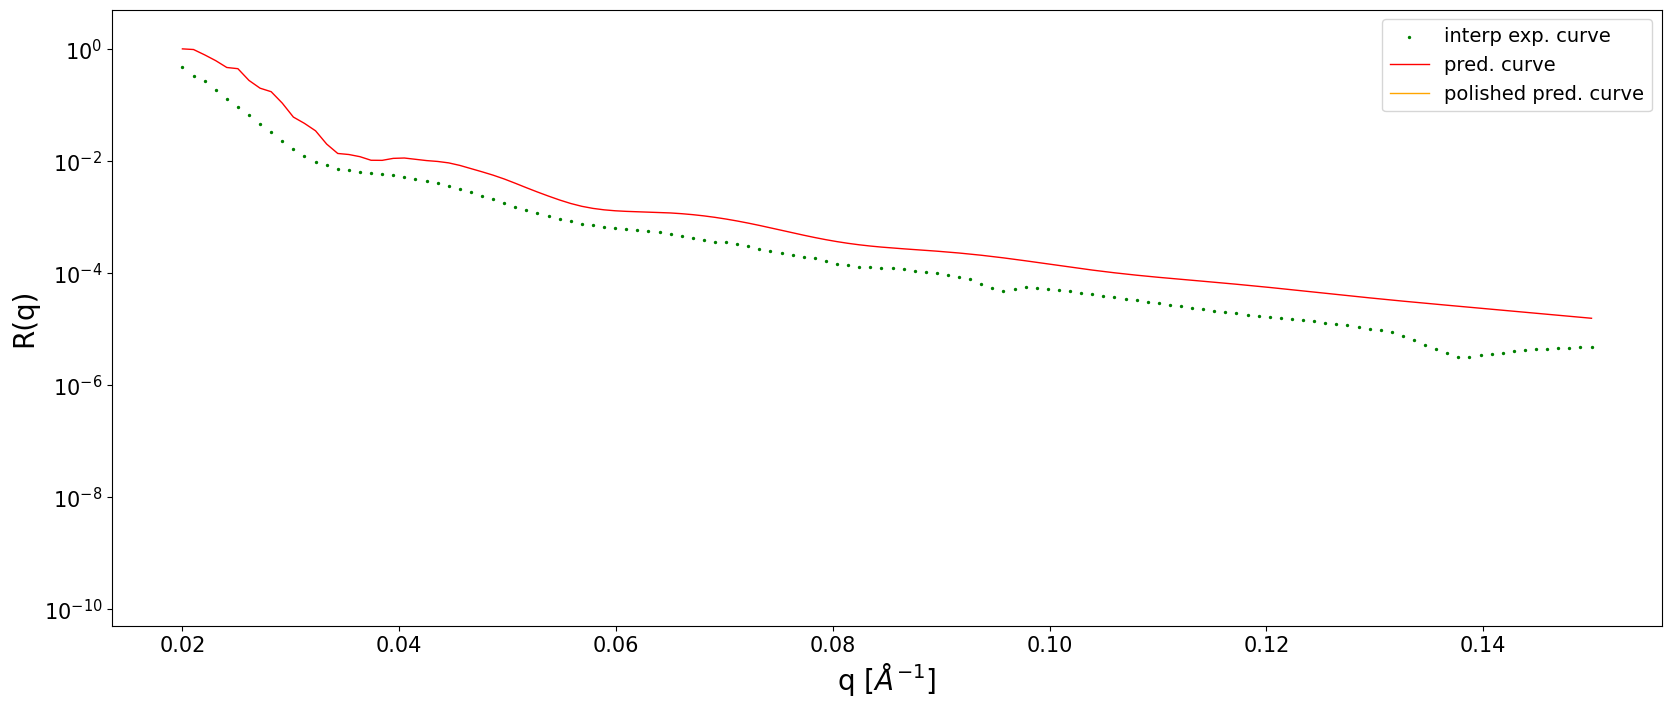

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
ax.set_yscale("log")
ax.set_ylim(0.5e-10, 5)
ax.set_xlabel("q [$Å^{-1}$]", fontsize=20)
ax.set_ylabel("R(q)", fontsize=20)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.tick_params(axis="both", which="minor", labelsize=15)
y_tick_locations = [10 ** (-2 * i) for i in range(6)]
ax.yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))

ax.scatter(q_model, exp_curve_interp, c="g", s=2, label="interp exp. curve")
ax.plot(q_model, pred_curve, c="r", lw=1, label="pred. curve")
ax.plot(
    q_model,
    prediction_dict["polished_curve"],
    c="orange",
    lw=1,
    label="polished pred. curve",
)

ax.legend(loc="upper right", fontsize=14);